In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gp = pd.read_csv('epraccur.csv', header=None, encoding='latin-1')
print("GP data shape:", gp.shape)
print(gp.head())


GP data shape: (15559, 27)
       0                           1    2    3               4   \
0  A81001         THE DENSHAM SURGERY  Y63  QHM   HEALTH CENTRE   
1  A81002  QUEENS PARK MEDICAL CENTRE  Y63  QHM   FARRER STREET   
2  A81003   VICTORIA MEDICAL PRACTICE  Y63  QHM   HEALTH CENTRE   
3  A81004       ACKLAM MEDICAL CENTRE  Y63  QHM  TRIMDON AVENUE   
4  A81005          SPRINGWOOD SURGERY  Y63  QHM    RECTORY LANE   

              5    6                 7   8         9   ...            17  18  \
0  LAWSON STREET  NaN  STOCKTON-ON-TEES NaN  TS18 1HU  ...  01642 672351 NaN   
1            NaN  NaN  STOCKTON ON TEES NaN  TS18 2AW  ...  01642 618170 NaN   
2  VICTORIA ROAD  NaN        HARTLEPOOL NaN  TS26 8DB  ...  01429 272945 NaN   
3         ACKLAM  NaN     MIDDLESBROUGH NaN   TS5 8SB  ...  01642 827697 NaN   
4            NaN  NaN       GUISBOROUGH NaN  TS14 7DJ  ...  01287 619611 NaN   

   19  20 21  22   23  24    25  26  
0 NaN NaN  1 NaN  16C NaN  RO76 NaN  
1 NaN NaN  1 

In [3]:
gp_clean = gp[[0, 1, 9]].copy()
gp_clean.columns = ['practice_code', 'practice_name', 'postcode']

print(gp_clean.head())
print(f"\nTotal practices: {len(gp_clean)}")


  practice_code               practice_name  postcode
0        A81001         THE DENSHAM SURGERY  TS18 1HU
1        A81002  QUEENS PARK MEDICAL CENTRE  TS18 2AW
2        A81003   VICTORIA MEDICAL PRACTICE  TS26 8DB
3        A81004       ACKLAM MEDICAL CENTRE   TS5 8SB
4        A81005          SPRINGWOOD SURGERY  TS14 7DJ

Total practices: 15559


In [4]:
xl = pd.ExcelFile('Index_of_Multiple_Deprivation.xlsx')
print(xl.sheet_names)

['Notes', 'IMD25']


In [5]:
imd = pd.read_excel('Index_of_Multiple_Deprivation.xlsx', sheet_name='IMD25')
print("IMD data shape:", imd.shape)
print(imd.head())
print("\nColumn names:")
print(imd.columns.tolist())


IMD data shape: (33755, 6)
  LSOA code (2021)           LSOA name (2021)  \
0        E01000001        City of London 001A   
1        E01000002        City of London 001B   
2        E01000003        City of London 001C   
3        E01000005        City of London 001E   
4        E01000006  Barking and Dagenham 016A   

  Local Authority District code (2024) Local Authority District name (2024)  \
0                            E09000001                       City of London   
1                            E09000001                       City of London   
2                            E09000001                       City of London   
3                            E09000001                       City of London   
4                            E09000002                 Barking and Dagenham   

   Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)  \
0                                              26525                     
1                                              31203   

In [6]:
imd_clean = imd[['LSOA code (2021)', 'Local Authority District name (2024)', 
                  'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)',
                  'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA']].copy()

imd_clean.columns = ['lsoa_code', 'local_authority', 'imd_rank', 'imd_decile']

print(imd_clean.head())

   lsoa_code       local_authority  imd_rank  imd_decile
0  E01000001        City of London     26525           8
1  E01000002        City of London     31203          10
2  E01000003        City of London     25913           8
3  E01000005        City of London     14807           5
4  E01000006  Barking and Dagenham     10917           4


In [7]:
import zipfile
import os

# See what's in the zip file
with zipfile.ZipFile('pcodey63.zip', 'r') as z:
    print(z.namelist())

['pcodey63.csv', 'pcode.pdf']


In [8]:
with zipfile.ZipFile('pcodey63.zip', 'r') as z:
    z.extractall('.')

print("Extracted!")

Extracted!


In [9]:
postcode_lookup = pd.read_csv('pcodey63.csv', header=None, encoding='latin-1')
print("Shape:", postcode_lookup.shape)
print(postcode_lookup.head())

Shape: (340202, 3)
          0    1    2
0  BB18 6JH  QWO  36J
1  BB18 6JR  QWO  36J
2  BB18 6LB  QWO  36J
3  BB18 6LG  QWO  36J
4  BB8  6JR  QWO  36J


In [10]:
print("Column count:", postcode_lookup.shape[1])
print("\nFirst few rows:")
print(postcode_lookup.head(10))
print("\nUnique values in column 1:")
print(postcode_lookup[1].unique()[:10])

Column count: 3

First few rows:
          0    1    2
0  BB18 6JH  QWO  36J
1  BB18 6JR  QWO  36J
2  BB18 6LB  QWO  36J
3  BB18 6LG  QWO  36J
4  BB8  6JR  QWO  36J
5  BB8  6LB  QWO  36J
6  BB8  6LG  QWO  36J
7  BD1  1AA  QWO  36J
8  BD1  1AE  QWO  36J
9  BD1  1AF  QWO  36J

Unique values in column 1:
<StringArray>
['QWO', 'QOQ', 'QHM', 'QF7']
Length: 4, dtype: str


In [11]:
import zipfile
import os

# Unzip the file
zip_path = "PCD_OA21_LSOA2.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())  # let's see what's inside first
    z.extractall()


['PCD_OA21_LSOA21_MSOA21_LAD_MAY25_UK_LU.csv']


In [12]:
# Load the postcode lookup
lookup = pd.read_csv('PCD_OA21_LSOA21_MSOA21_LAD_MAY25_UK_LU.csv', 
                     usecols=['pcds', 'lsoa21cd'],
                     dtype=str)

print(lookup.shape)
print(lookup.head())

(2714964, 2)
      pcds   lsoa21cd
0  AB1 0AA  S01013490
1  AB1 0AB  S01013490
2  AB1 0AD  S01013490
3  AB1 0AE  S01013856
4  AB1 0AF  S01013487


In [13]:
# Standardise postcode format in both dataframes
gp_clean['postcode'] = gp_clean['postcode'].str.strip().str.upper()
lookup['pcds'] = lookup['pcds'].str.strip().str.upper()

# Merge GP practices with postcode lookup
gp_lsoa = gp_clean.merge(lookup, 
                          left_on='postcode', 
                          right_on='pcds', 
                          how='left')

print(gp_lsoa.shape)
print(gp_lsoa.head())
print(f"\nMissing LSOAs: {gp_lsoa['lsoa21cd'].isna().sum()}")

(15559, 5)
  practice_code               practice_name  postcode      pcds   lsoa21cd
0        A81001         THE DENSHAM SURGERY  TS18 1HU  TS18 1HU  E01035199
1        A81002  QUEENS PARK MEDICAL CENTRE  TS18 2AW  TS18 2AW  E01012267
2        A81003   VICTORIA MEDICAL PRACTICE  TS26 8DB  TS26 8DB  E01011999
3        A81004       ACKLAM MEDICAL CENTRE   TS5 8SB   TS5 8SB  E01012024
4        A81005          SPRINGWOOD SURGERY  TS14 7DJ  TS14 7DJ  E01012117

Missing LSOAs: 23


In [14]:
# Merge with IMD data
gp_imd = gp_lsoa.merge(imd_clean,
                        left_on='lsoa21cd',
                        right_on='lsoa_code',
                        how='left')

# Drop the redundant columns
gp_imd = gp_imd.drop(columns=['pcds', 'lsoa_code'])

print(gp_imd.shape)
print(gp_imd.head())
print(f"\nMissing IMD scores: {gp_imd['imd_decile'].isna().sum()}")

(15559, 7)
  practice_code               practice_name  postcode   lsoa21cd  \
0        A81001         THE DENSHAM SURGERY  TS18 1HU  E01035199   
1        A81002  QUEENS PARK MEDICAL CENTRE  TS18 2AW  E01012267   
2        A81003   VICTORIA MEDICAL PRACTICE  TS26 8DB  E01011999   
3        A81004       ACKLAM MEDICAL CENTRE   TS5 8SB  E01012024   
4        A81005          SPRINGWOOD SURGERY  TS14 7DJ  E01012117   

        local_authority  imd_rank  imd_decile  
0      Stockton-on-Tees      98.0         1.0  
1      Stockton-on-Tees     244.0         1.0  
2            Hartlepool      80.0         1.0  
3         Middlesbrough   21705.0         7.0  
4  Redcar and Cleveland    8118.0         3.0  

Missing IMD scores: 750


In [15]:
# Save the merged dataframe
gp_imd.to_csv('gp_imd_merged.csv', index=False)

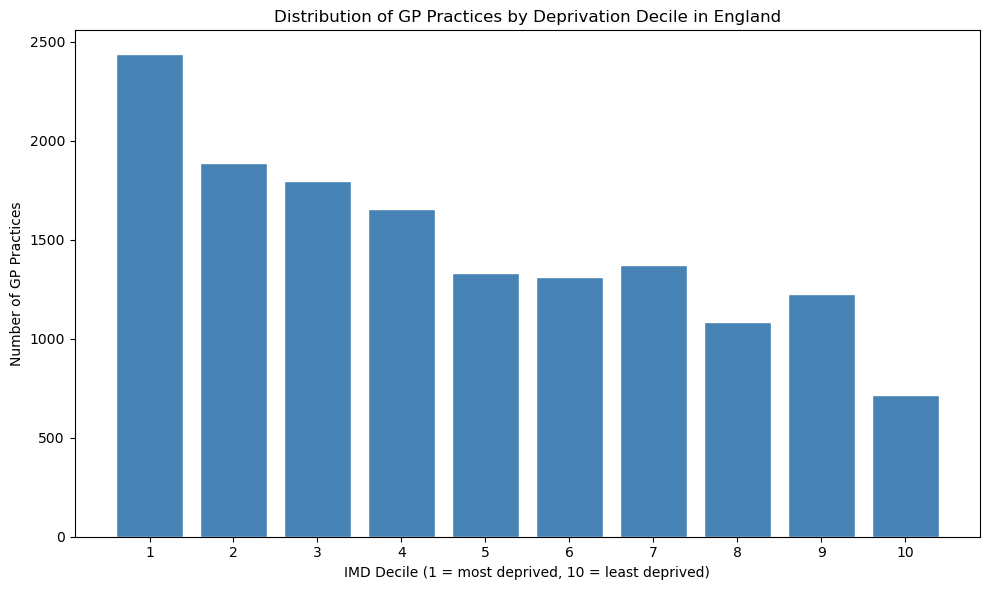

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Count GP practices per IMD decile
decile_counts = gp_imd['imd_decile'].value_counts().sort_index()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(decile_counts.index, decile_counts.values, color='steelblue', edgecolor='white')

ax.set_xlabel('IMD Decile (1 = most deprived, 10 = least deprived)')
ax.set_ylabel('Number of GP Practices')
ax.set_title('Distribution of GP Practices by Deprivation Decile in England')
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [17]:
import zipfile

with zipfile.ZipFile('gp-reg-pat-prac-all.zip', 'r') as z:
    print(z.namelist())

['gp-reg-pat-prac-all.csv']


In [18]:
list_sizes = pd.read_csv('gp-reg-pat-prac-all.zip', compression='zip')

print(list_sizes.shape)
print(list_sizes.head())
print(list_sizes.columns.tolist())

(6239, 10)
        PUBLICATION EXTRACT_DATE TYPE SUB_ICB_LOCATION_CODE  \
0  GP_PRAC_PAT_LIST   2025-04-01   GP                   16C   
1  GP_PRAC_PAT_LIST   2025-04-01   GP                   16C   
2  GP_PRAC_PAT_LIST   2025-04-01   GP                   16C   
3  GP_PRAC_PAT_LIST   2025-04-01   GP                   16C   
4  GP_PRAC_PAT_LIST   2025-04-01   GP                   16C   

  ONS_SUB_ICB_LOCATION_CODE    CODE  POSTCODE  SEX  AGE  NUMBER_OF_PATIENTS  
0                 E38000247  A81001  TS18 1HU  ALL  ALL                3904  
1                 E38000247  A81002  TS18 2AW  ALL  ALL               18758  
2                 E38000247  A81004   TS5 8SB  ALL  ALL               11346  
3                 E38000247  A81005  TS14 7DJ  ALL  ALL                7677  
4                 E38000247  A81006  TS18 2AT  ALL  ALL               14708  
['PUBLICATION', 'EXTRACT_DATE', 'TYPE', 'SUB_ICB_LOCATION_CODE', 'ONS_SUB_ICB_LOCATION_CODE', 'CODE', 'POSTCODE', 'SEX', 'AGE', 'NUMBER_OF_PAT

In [19]:
list_sizes_clean = list_sizes[
    (list_sizes['SEX'] == 'ALL') & 
    (list_sizes['AGE'] == 'ALL')
][['CODE', 'NUMBER_OF_PATIENTS']].copy()

list_sizes_clean.columns = ['practice_code', 'list_size']

print(list_sizes_clean.shape)
print(list_sizes_clean.head())

(6239, 2)
  practice_code  list_size
0        A81001       3904
1        A81002      18758
2        A81004      11346
3        A81005       7677
4        A81006      14708


In [20]:
gp_full = gp_imd.merge(list_sizes_clean, 
                        on='practice_code', 
                        how='left')

print(gp_full.shape)
print(gp_full.head())
print(f"\nMissing list sizes: {gp_full['list_size'].isna().sum()}")

(15559, 8)
  practice_code               practice_name  postcode   lsoa21cd  \
0        A81001         THE DENSHAM SURGERY  TS18 1HU  E01035199   
1        A81002  QUEENS PARK MEDICAL CENTRE  TS18 2AW  E01012267   
2        A81003   VICTORIA MEDICAL PRACTICE  TS26 8DB  E01011999   
3        A81004       ACKLAM MEDICAL CENTRE   TS5 8SB  E01012024   
4        A81005          SPRINGWOOD SURGERY  TS14 7DJ  E01012117   

        local_authority  imd_rank  imd_decile  list_size  
0      Stockton-on-Tees      98.0         1.0     3904.0  
1      Stockton-on-Tees     244.0         1.0    18758.0  
2            Hartlepool      80.0         1.0        NaN  
3         Middlesbrough   21705.0         7.0    11346.0  
4  Redcar and Cleveland    8118.0         3.0     7677.0  

Missing list sizes: 9320


In [21]:
# How many practices have BOTH an IMD decile AND a list size?
gp_active = gp_full[
    (gp_full['imd_decile'].notna()) & 
    (gp_full['list_size'].notna())
].copy()

print(gp_active.shape)
print(gp_active['imd_decile'].value_counts().sort_index())

(6237, 8)
imd_decile
1.0     984
2.0     848
3.0     779
4.0     709
5.0     601
6.0     573
7.0     540
8.0     463
9.0     465
10.0    275
Name: count, dtype: int64


In [22]:
# Average list size per practice by IMD decile
list_by_decile = gp_active.groupby('imd_decile')['list_size'].mean().round(0)
print(list_by_decile)

imd_decile
1.0      9272.0
2.0      9737.0
3.0     10101.0
4.0     10429.0
5.0     10095.0
6.0     10347.0
7.0     10295.0
8.0     10939.0
9.0     11219.0
10.0    11962.0
Name: list_size, dtype: float64


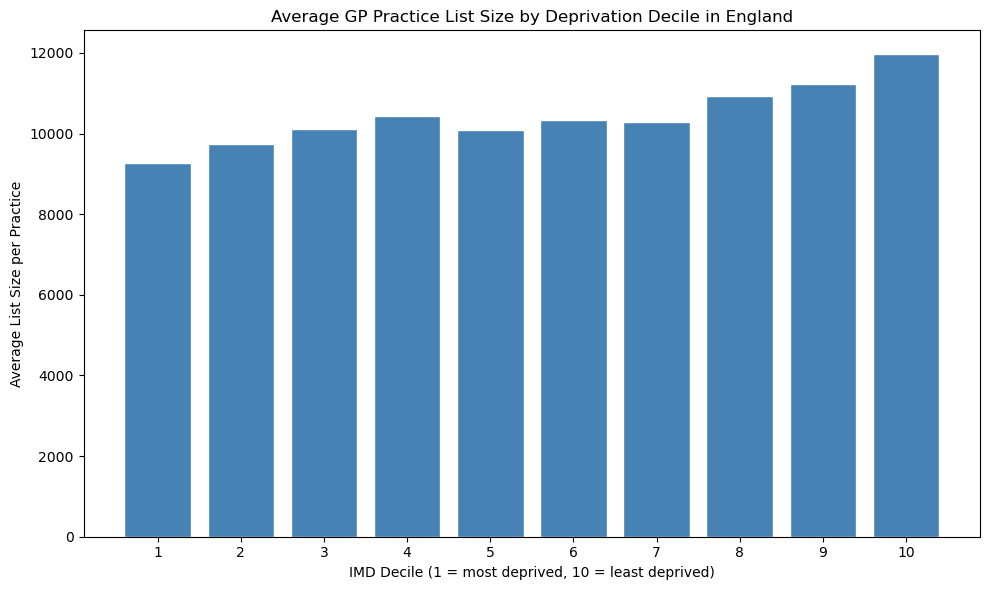

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(list_by_decile.index, list_by_decile.values, color='steelblue', edgecolor='white')

ax.set_xlabel('IMD Decile (1 = most deprived, 10 = least deprived)')
ax.set_ylabel('Average List Size per Practice')
ax.set_title('Average GP Practice List Size by Deprivation Decile in England')
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [25]:
import numpy as np

# Summary statistics of list sizes
print(gp_active['list_size'].describe())

# Let's also look at some percentiles
percentiles = [10, 25, 50, 75, 90]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(gp_active['list_size'], p):.0f}")

count      6237.000000
mean      10224.437550
std        7031.422293
min           1.000000
25%        5831.000000
50%        8758.000000
75%       12693.000000
max      100329.000000
Name: list_size, dtype: float64
10th percentile: 3870
25th percentile: 5831
50th percentile: 8758
75th percentile: 12693
90th percentile: 17673


In [26]:
# Define small practices
gp_active['small_practice'] = gp_active['list_size'] < 5000

# Count small practices by IMD decile
small_by_decile = gp_active.groupby('imd_decile')['small_practice'].agg(['sum', 'count'])
small_by_decile.columns = ['small_practices', 'total_practices']
small_by_decile['percentage_small'] = (small_by_decile['small_practices'] / small_by_decile['total_practices'] * 100).round(1)

print(small_by_decile)

            small_practices  total_practices  percentage_small
imd_decile                                                    
1.0                     240              984              24.4
2.0                     187              848              22.1
3.0                     130              779              16.7
4.0                     119              709              16.8
5.0                     136              601              22.6
6.0                      93              573              16.2
7.0                      87              540              16.1
8.0                      54              463              11.7
9.0                      57              465              12.3
10.0                     24              275               8.7


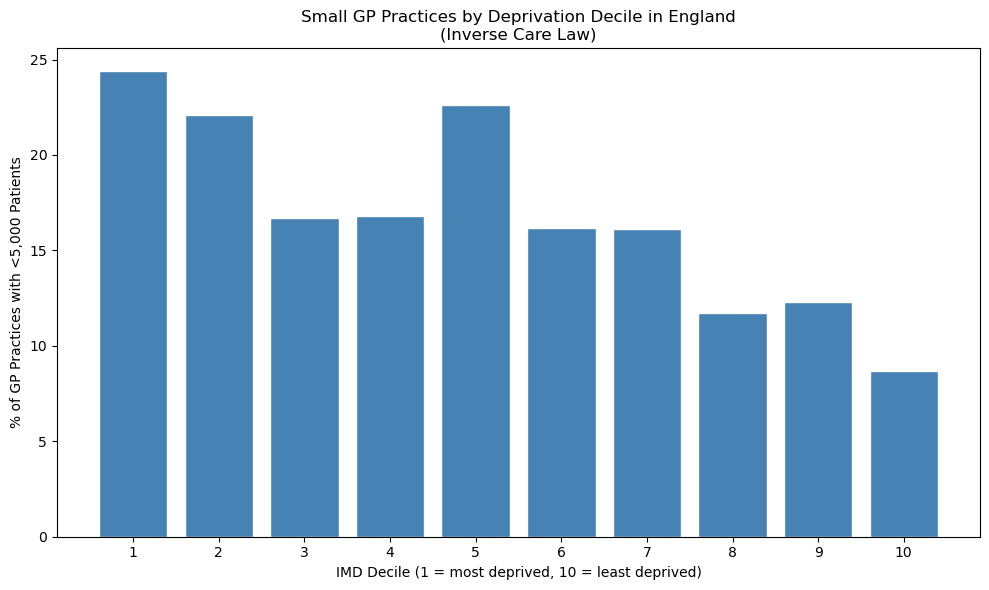

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(small_by_decile.index, small_by_decile['percentage_small'], 
       color='steelblue', edgecolor='white')

ax.set_xlabel('IMD Decile (1 = most deprived, 10 = least deprived)')
ax.set_ylabel('% of GP Practices with <5,000 Patients')
ax.set_title('Small GP Practices by Deprivation Decile in England\n(Inverse Care Law)')
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()
